# Anomaly Detection

## Financial Services Performance Analytics Platform

### Objective

Identify statistically unusual completed transactions based on transaction amounts using the Interquartile Range (IQR) method.

The analysis also examines anomaly patterns across transaction channels, transaction types, and merchant categories.

**Analysis Period:** January 2024 – December 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
transactions = pd.read_csv("../data/raw/transactions.csv")

transactions.head()

,transaction_id,customer_id,account_id,transaction_date,transaction_type,amount,merchant_category,channel,status
0,1,3433,971,2024-08-04,Payment,46.54,Transportation,Online,Completed
1,2,1279,3842,2025-06-23,Payment,83.94,Healthcare,Branch,Completed
2,3,103,6447,2024-02-27,Deposit,15.70,Retail,Phone,Pending
3,4,1882,4429,2025-02-03,Transfer,17.43,Grocery,Mobile,Failed
4,5,4031,3594,2025-09-15,Deposit,87.22,Travel,Branch,Failed


In [3]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

completed = transactions[transactions["status"] == "Completed"].copy()

completed.shape

(66683, 9)

In [4]:
# Calculate IQR Statistics
q1 = completed["amount"].quantile(0.25)

median_amount = completed["amount"].median()

q3 = completed["amount"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)

upper_bound = q3 + (1.5 * iqr)

print("Q1:", round(q1, 2))
print("Median:", round(median_amount, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))

Q1: 27.91
Median: 55.21
Q3: 109.25
IQR: 81.34
Lower Bound: -94.1
Upper Bound: 231.26


In [5]:
#  Create Anomaly Flag
completed["anomaly_status"] = "Normal"

completed.loc[
    completed["amount"] > upper_bound,
    "anomaly_status"
] = "High Amount Anomaly"

completed.loc[
    completed["amount"] < lower_bound,
    "anomaly_status"
] = "Low Amount Anomaly"

In [6]:
# Count Anomalies
anomaly_counts = (
    completed["anomaly_status"]
    .value_counts()
    .reset_index()
)

anomaly_counts.columns = [
    "anomaly_status",
    "transaction_count"
]

anomaly_counts

,anomaly_status,transaction_count
0,Normal,61142
1,High Amount Anomaly,5541


In [7]:
# Calculate Anomaly Rate
total_completed = len(completed)

total_anomalies = (
    completed["anomaly_status"] != "Normal"
).sum()

anomaly_rate = (
    total_anomalies / total_completed
) * 100

print(
    f"Total completed transactions: {total_completed:,}"
)

print(
    f"Total anomalies: {total_anomalies:,}"
)

print(
    f"Overall anomaly rate: {anomaly_rate:.2f}%"
)

Total completed transactions: 66,683
Total anomalies: 5,541
Overall anomaly rate: 8.31%


In [8]:
# Top Anomalies
top_anomalies = (
    completed[
        completed["anomaly_status"] == "High Amount Anomaly"
    ]
    .sort_values(
        "amount",
        ascending=False
    )
    .head(20)
)

top_anomalies[
    [
        "transaction_id",
        "customer_id",
        "transaction_date",
        "amount",
        "transaction_type",
        "merchant_category",
        "channel"
    ]
]

,transaction_id,customer_id,transaction_date,amount,transaction_type,merchant_category,channel
38740,38741,450,2024-08-01,49924.20,Transfer,Dining,Mobile
81938,81939,98,2024-05-31,49681.50,Withdrawal,Education,Online
39031,39032,179,2024-11-03,49659.60,Purchase,Utilities,Phone
7020,7021,1520,2024-10-28,49630.85,Purchase,Transportation,Phone
75342,75343,3110,2024-08-15,49539.00,Payment,Travel,Mobile
80124,80125,3412,2025-06-29,49517.79,Transfer,Entertainment,Phone
67402,67403,1835,2024-03-15,49478.33,Payment,Entertainment,ATM
22492,22493,2319,2025-06-05,49362.84,Withdrawal,Grocery,ATM
88786,88787,4894,2025-11-12,49308.12,Purchase,Grocery,ATM
3917,3918,2967,2025-02-16,49307.56,Purchase,Travel,Phone


In [9]:
# Anomalies by Channel
channel_analysis = (
    completed
    .groupby("channel")
    .agg(
        total_transactions=("transaction_id", "count"),
        anomaly_transactions=(
            "anomaly_status",
            lambda x: (x != "Normal").sum()
        )
    )
    .reset_index()
)

channel_analysis["anomaly_rate_percent"] = (
    channel_analysis["anomaly_transactions"]
    / channel_analysis["total_transactions"]
) * 100

channel_analysis.sort_values(
    "anomaly_rate_percent",
    ascending=False
)

,channel,total_transactions,anomaly_transactions,anomaly_rate_percent
1,Branch,13435,1151,8.567175
0,ATM,13324,1115,8.368358
2,Mobile,13288,1106,8.323299
4,Phone,13251,1084,8.180515
3,Online,13385,1085,8.106089


In [10]:
#  Anomalies by Transaction Type
transaction_type_analysis = (
    completed
    .groupby("transaction_type")
    .agg(
        total_transactions=("transaction_id", "count"),
        anomaly_transactions=(
            "anomaly_status",
            lambda x: (x != "Normal").sum()
        )
    )
    .reset_index()
)

transaction_type_analysis["anomaly_rate_percent"] = (
    transaction_type_analysis["anomaly_transactions"]
    / transaction_type_analysis["total_transactions"]
) * 100

transaction_type_analysis.sort_values(
    "anomaly_rate_percent",
    ascending=False
)

,transaction_type,total_transactions,anomaly_transactions,anomaly_rate_percent
3,Transfer,13295,1135,8.537044
1,Payment,13365,1137,8.507295
2,Purchase,13222,1081,8.175768
0,Deposit,13228,1080,8.164500
4,Withdrawal,13573,1108,8.163265


In [11]:
# Anomalies by Merchant Category
merchant_analysis = (
    completed
    .groupby("merchant_category")
    .agg(
        total_transactions=("transaction_id", "count"),
        anomaly_transactions=(
            "anomaly_status",
            lambda x: (x != "Normal").sum()
        )
    )
    .reset_index()
)

merchant_analysis["anomaly_rate_percent"] = (
    merchant_analysis["anomaly_transactions"]
    / merchant_analysis["total_transactions"]
) * 100

merchant_analysis.sort_values(
    "anomaly_rate_percent",
    ascending=False
)

,merchant_category,total_transactions,anomaly_transactions,anomaly_rate_percent
2,Entertainment,7532,653,8.669676
0,Dining,7281,622,8.542783
8,Utilities,7345,619,8.427502
4,Healthcare,7482,625,8.353381
6,Transportation,7426,616,8.295179
1,Education,7359,609,8.275581
7,Travel,7417,609,8.210867
3,Grocery,7454,612,8.210357
5,Retail,7387,576,7.797482


## Anomaly Distribution

This section visualizes the distribution of normal transactions and potential transaction amount anomalies identified using the IQR method.

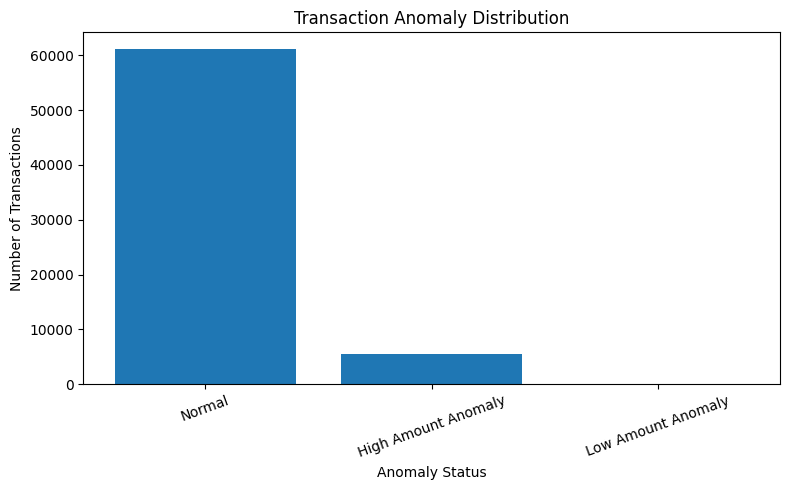

In [12]:
import matplotlib.pyplot as plt

anomaly_counts = (
    completed["anomaly_status"]
    .value_counts()
    .reindex(["Normal", "High Amount Anomaly", "Low Amount Anomaly"], fill_value=0)
)

plt.figure(figsize=(8, 5))

plt.bar(
    anomaly_counts.index,
    anomaly_counts.values
)

plt.title("Transaction Anomaly Distribution")
plt.xlabel("Anomaly Status")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

## Anomaly Rates by Channel

This analysis compares the percentage of potential transaction amount anomalies across transaction channels.

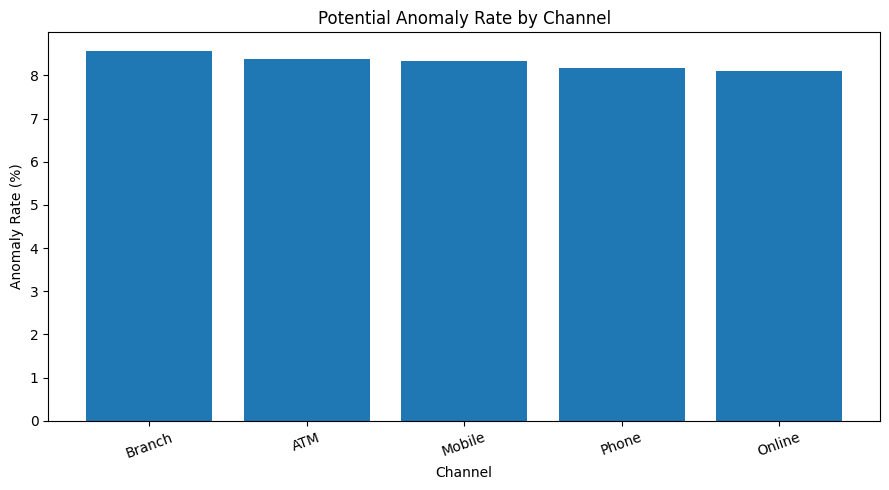

In [13]:
channel_chart = channel_analysis.sort_values(
    "anomaly_rate_percent",
    ascending=False
)

plt.figure(figsize=(9, 5))

plt.bar(
    channel_chart["channel"],
    channel_chart["anomaly_rate_percent"]
)

plt.title("Potential Anomaly Rate by Channel")
plt.xlabel("Channel")
plt.ylabel("Anomaly Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

## Anomaly Rates by Transaction Type

This analysis compares potential transaction amount anomaly rates across different transaction types.

,transaction_type,total_transactions,anomaly_transactions,anomaly_rate_percent
3,Transfer,13295,1135,8.537044
1,Payment,13365,1137,8.507295
2,Purchase,13222,1081,8.175768
0,Deposit,13228,1080,8.164500
4,Withdrawal,13573,1108,8.163265


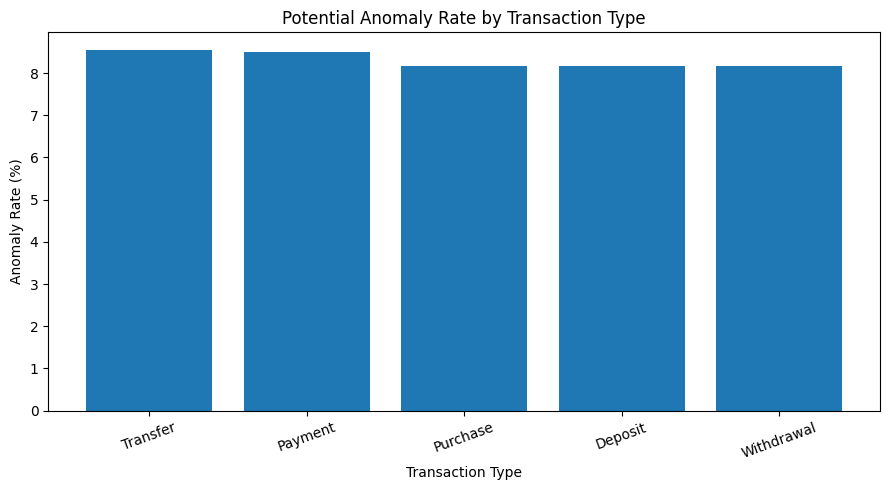

In [14]:
# Transaction Type Analysis and Visualization

type_analysis = (
    completed
    .groupby("transaction_type")
    .agg(
        total_transactions=("transaction_id", "count"),
        anomaly_transactions=(
            "anomaly_status",
            lambda x: (x != "Normal").sum()
        )
    )
    .reset_index()
)

type_analysis["anomaly_rate_percent"] = (
    type_analysis["anomaly_transactions"]
    / type_analysis["total_transactions"]
) * 100

type_analysis = type_analysis.sort_values(
    "anomaly_rate_percent",
    ascending=False
)

display(type_analysis)

# Visualization

plt.figure(figsize=(9, 5))

plt.bar(
    type_analysis["transaction_type"],
    type_analysis["anomaly_rate_percent"]
)

plt.title("Potential Anomaly Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Anomaly Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

## Anomaly Rates by Merchant Category

This analysis compares potential transaction amount anomaly rates across merchant categories.

In [15]:
# Anomalies by Merchant Category

merchant_analysis = (
    completed
    .groupby("merchant_category")
    .agg(
        total_transactions=("transaction_id", "count"),
        anomaly_transactions=(
            "anomaly_status",
            lambda x: (x != "Normal").sum()
        )
    )
    .reset_index()
)

merchant_analysis["anomaly_rate_percent"] = (
    merchant_analysis["anomaly_transactions"]
    / merchant_analysis["total_transactions"]
) * 100

merchant_analysis = merchant_analysis.sort_values(
    "anomaly_rate_percent",
    ascending=False
)

display(merchant_analysis)

,merchant_category,total_transactions,anomaly_transactions,anomaly_rate_percent
2,Entertainment,7532,653,8.669676
0,Dining,7281,622,8.542783
8,Utilities,7345,619,8.427502
4,Healthcare,7482,625,8.353381
6,Transportation,7426,616,8.295179
1,Education,7359,609,8.275581
7,Travel,7417,609,8.210867
3,Grocery,7454,612,8.210357
5,Retail,7387,576,7.797482


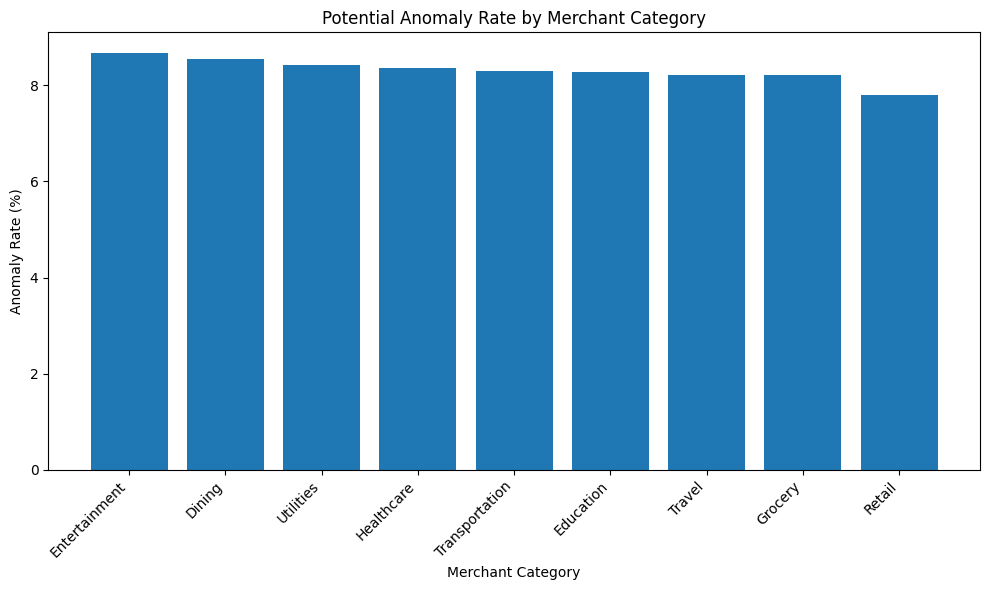

In [16]:
plt.figure(figsize=(10, 6))

plt.bar(
    merchant_analysis["merchant_category"],
    merchant_analysis["anomaly_rate_percent"]
)

plt.title("Potential Anomaly Rate by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Anomaly Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## Transaction Amount Distribution

The histogram below shows the distribution of completed transaction amounts. The upper IQR threshold is displayed to identify transactions with unusually high amounts.

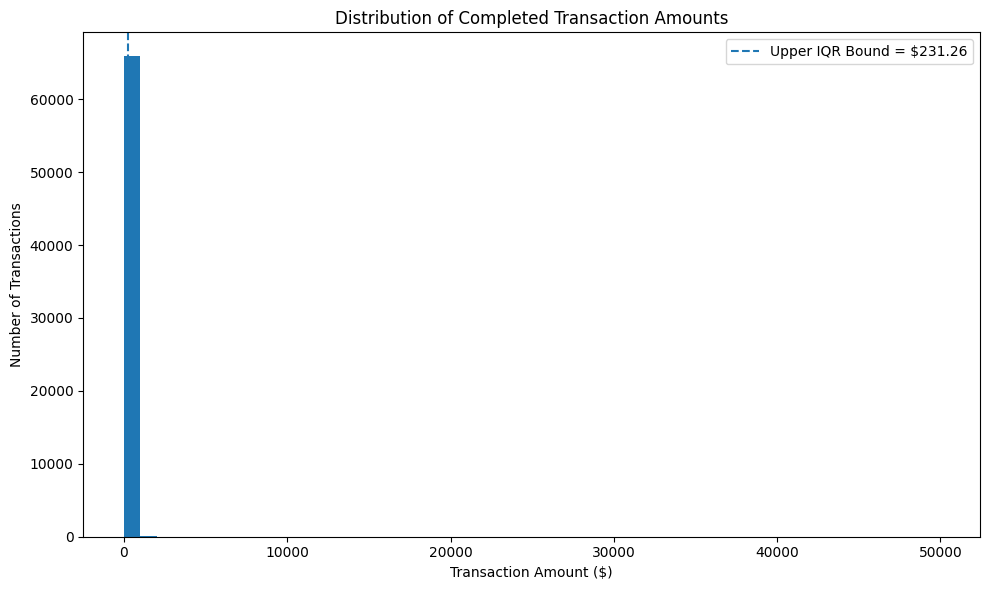

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(
    completed["amount"],
    bins=50
)

plt.axvline(
    upper_bound,
    linestyle="--",
    label=f"Upper IQR Bound = ${upper_bound:.2f}"
)

plt.title("Distribution of Completed Transaction Amounts")
plt.xlabel("Transaction Amount ($)")
plt.ylabel("Number of Transactions")
plt.legend()
plt.tight_layout()

plt.show()

## Top Potential Transaction Amount Anomalies

The following transactions represent the largest completed transaction amounts identified as potential anomalies using the IQR method.

In [18]:
top_anomalies = (
    completed[
        completed["anomaly_status"] != "Normal"
    ]
    .sort_values("amount", ascending=False)
)

top_anomalies[
    [
        "transaction_id",
        "customer_id",
        "transaction_date",
        "transaction_type",
        "amount",
        "merchant_category",
        "channel",
        "anomaly_status"
    ]
].head(10)

,transaction_id,customer_id,transaction_date,transaction_type,amount,merchant_category,channel,anomaly_status
38740,38741,450,2024-08-01,Transfer,49924.20,Dining,Mobile,High Amount Anomaly
81938,81939,98,2024-05-31,Withdrawal,49681.50,Education,Online,High Amount Anomaly
39031,39032,179,2024-11-03,Purchase,49659.60,Utilities,Phone,High Amount Anomaly
7020,7021,1520,2024-10-28,Purchase,49630.85,Transportation,Phone,High Amount Anomaly
75342,75343,3110,2024-08-15,Payment,49539.00,Travel,Mobile,High Amount Anomaly
80124,80125,3412,2025-06-29,Transfer,49517.79,Entertainment,Phone,High Amount Anomaly
67402,67403,1835,2024-03-15,Payment,49478.33,Entertainment,ATM,High Amount Anomaly
22492,22493,2319,2025-06-05,Withdrawal,49362.84,Grocery,ATM,High Amount Anomaly
88786,88787,4894,2025-11-12,Purchase,49308.12,Grocery,ATM,High Amount Anomaly
3917,3918,2967,2025-02-16,Purchase,49307.56,Travel,Phone,High Amount Anomaly


## Key Findings

- The IQR method identified potential transaction amount anomalies among completed transactions.
- The upper anomaly threshold was approximately $231.26.
- No low-amount anomalies were identified because the calculated lower bound was negative while transaction amounts were positive.
- Most identified anomalies were high-amount transactions.
- Anomaly rates were relatively similar across channels, transaction types, and merchant categories.
- These results identify statistically unusual transaction amounts and should not be interpreted as evidence of fraudulent activity.

In [19]:
print("ANOMALY DETECTION SUMMARY")
print("-" * 40)

print(f"Total completed transactions: {len(completed):,}")

anomaly_count = (
    completed["anomaly_status"] != "Normal"
).sum()

print(f"Potential anomalies: {anomaly_count:,}")

anomaly_rate = (
    anomaly_count / len(completed)
) * 100

print(f"Potential anomaly rate: {anomaly_rate:.2f}%")

print(f"Lower IQR bound: ${lower_bound:.2f}")
print(f"Upper IQR bound: ${upper_bound:.2f}")

print(
    f"Highest potential anomaly: "
    f"${top_anomalies['amount'].iloc[0]:,.2f}"
)

ANOMALY DETECTION SUMMARY
----------------------------------------
Total completed transactions: 66,683
Potential anomalies: 5,541
Potential anomaly rate: 8.31%
Lower IQR bound: $-94.10
Upper IQR bound: $231.26
Highest potential anomaly: $49,924.20
